import library yang di butuhkan

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

upload gambar - gambar ijazah yang akan di proses

In [ ]:
print("Silakan pilih dan upload semua gambar ijazah Anda:")
uploaded = files.upload()
image_names = list(uploaded.keys())
print("\nUploaded:", image_names)

Silakan pilih dan upload semua gambar ijazah Anda:


Saving 01_HighQuality_Enhanced (1).jpg to 01_HighQuality_Enhanced (1).jpg
Saving 02_LowContrast.jpg to 02_LowContrast.jpg
Saving 03_Blurred.jpg to 03_Blurred.jpg
Saving 04_HighNoise.jpg to 04_HighNoise.jpg
Saving 05_LowResolution_Upsampled.jpg to 05_LowResolution_Upsampled.jpg
Saving 06_Faded_Underexposed.jpg to 06_Faded_Underexposed.jpg
Saving 07_ColorShift_WarmTint.jpg to 07_ColorShift_WarmTint.jpg
Saving 08_JPEGCompression_Artifacts.jpg to 08_JPEGCompression_Artifacts.jpg
Saving 09_CombinedDegradation.jpg to 09_CombinedDegradation.jpg

Uploaded: ['01_HighQuality_Enhanced (1).jpg', '02_LowContrast.jpg', '03_Blurred.jpg', '04_HighNoise.jpg', '05_LowResolution_Upsampled.jpg', '06_Faded_Underexposed.jpg', '07_ColorShift_WarmTint.jpg', '08_JPEGCompression_Artifacts.jpg', '09_CombinedDegradation.jpg']


Mengurutkan nama file supaya tampilannya berurutan

In [ ]:
image_names = sorted(list(uploaded.keys()))

print(f"\nMemproses {len(image_names)} gambar untuk laporan...\n")


Memproses 9 gambar untuk laporan...



proses pengolahan citra

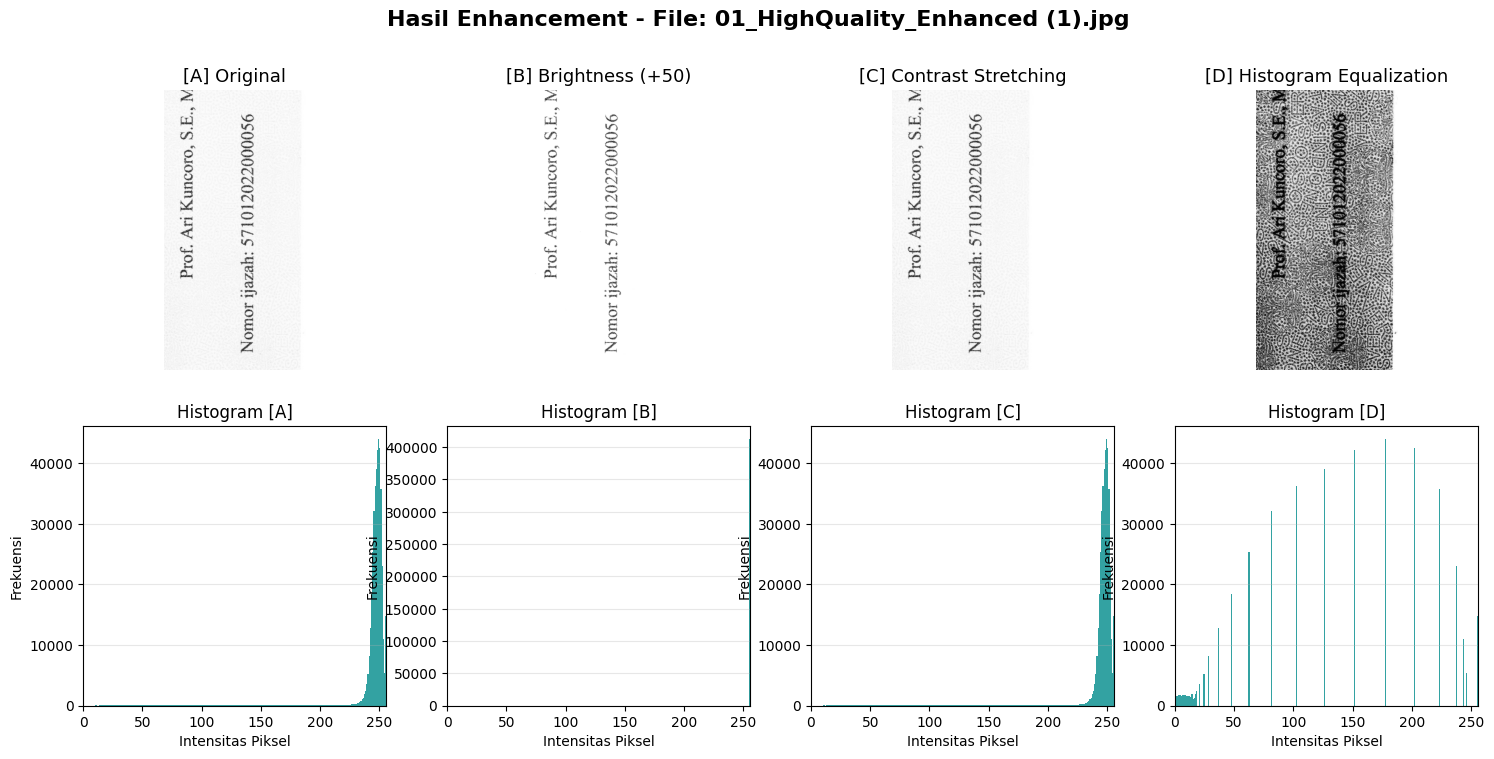

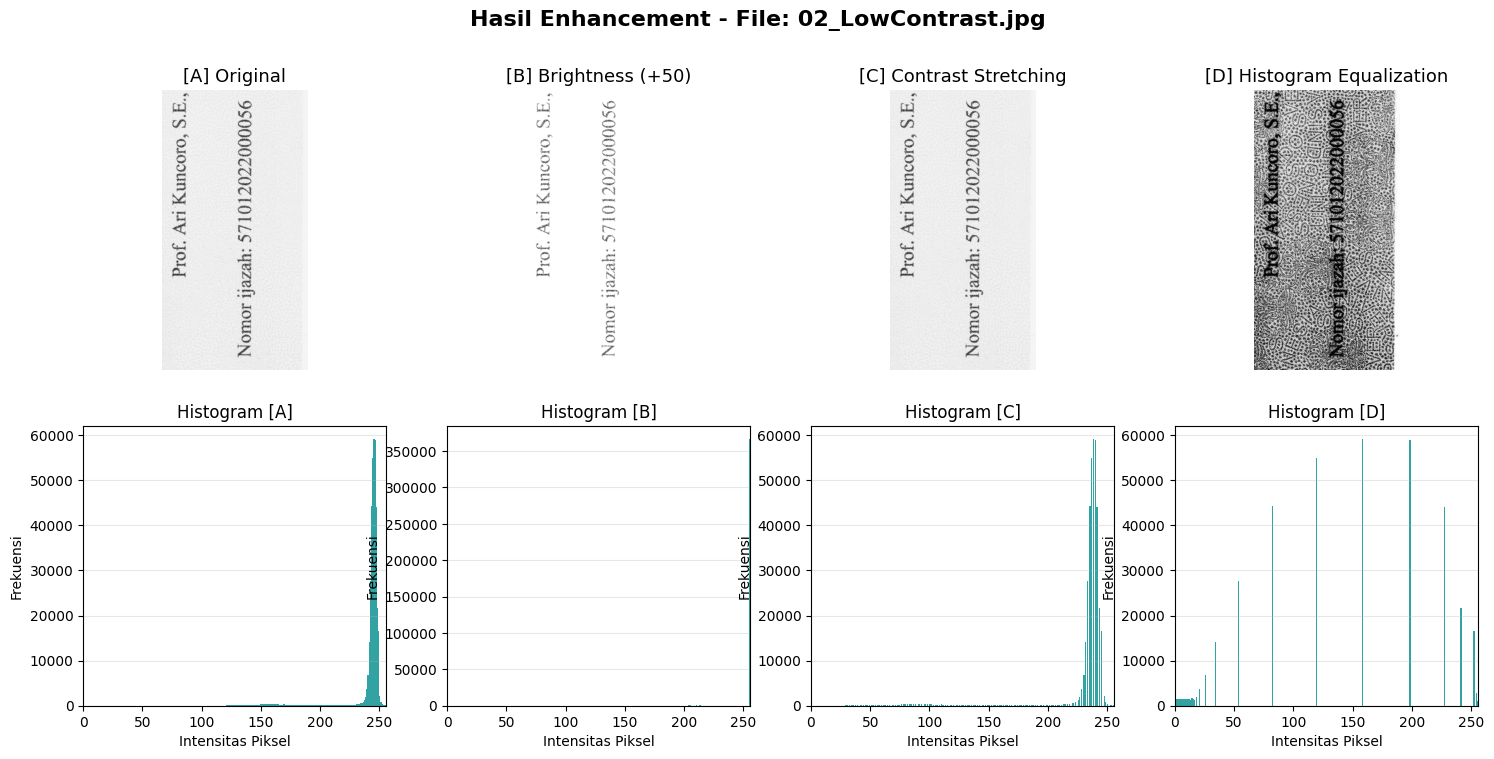

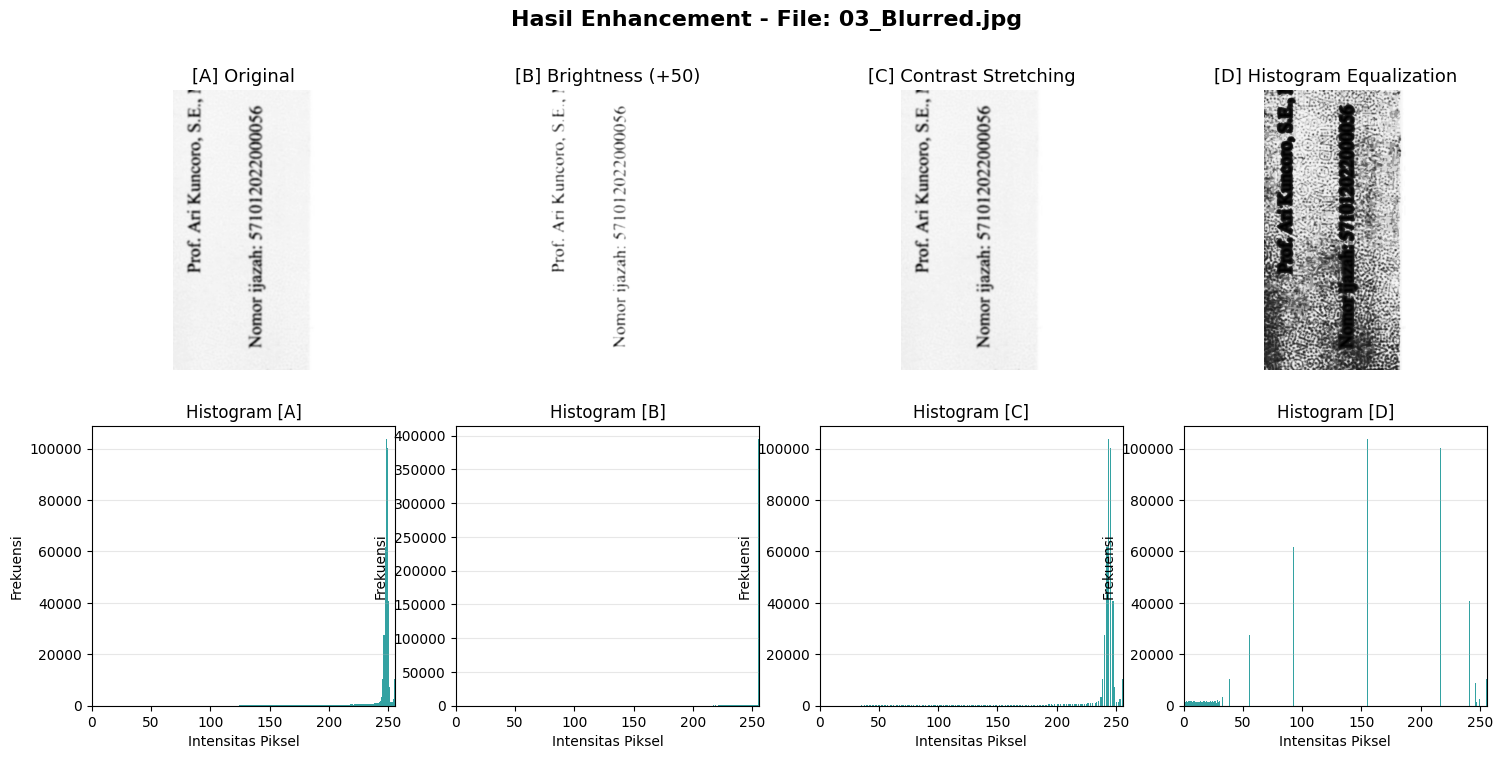

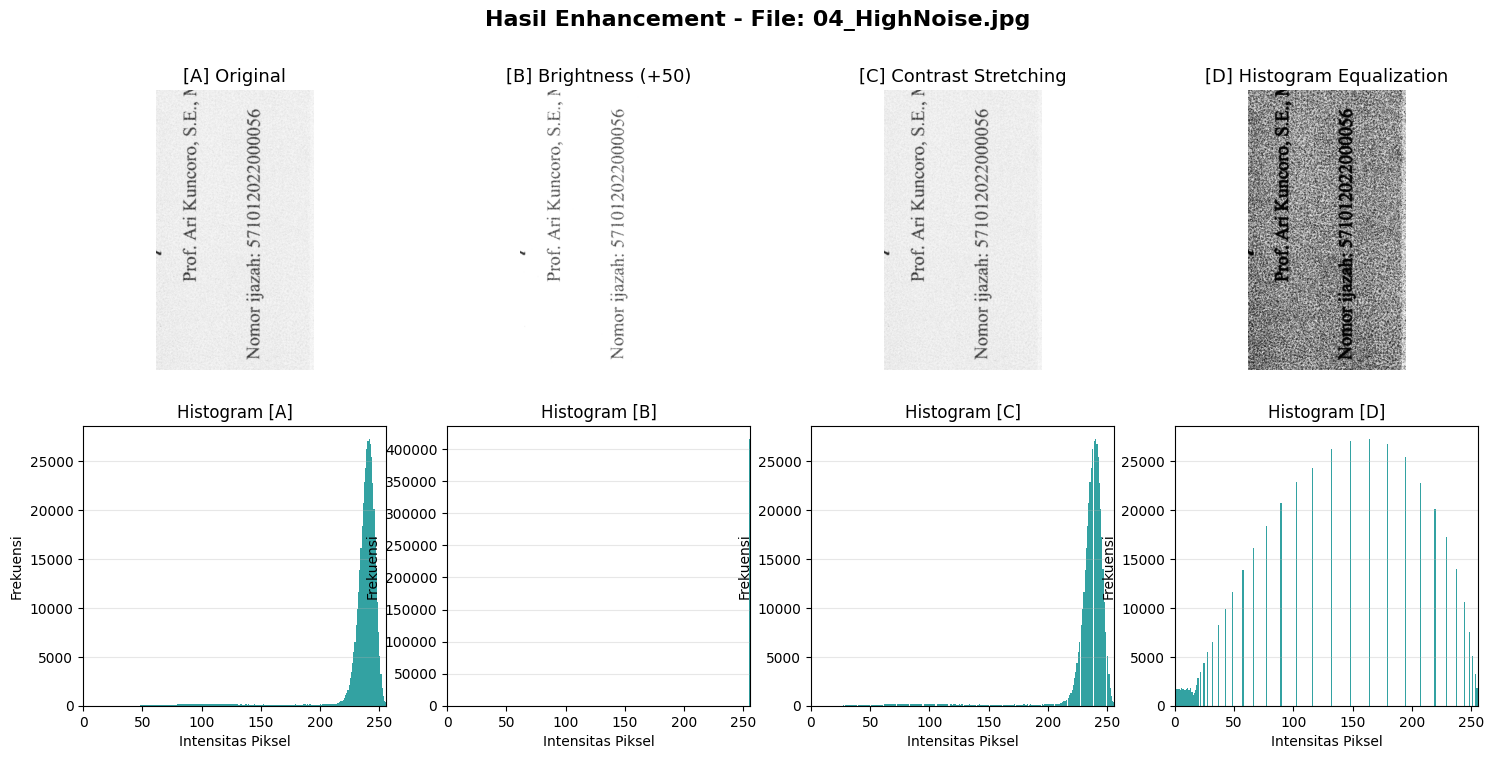

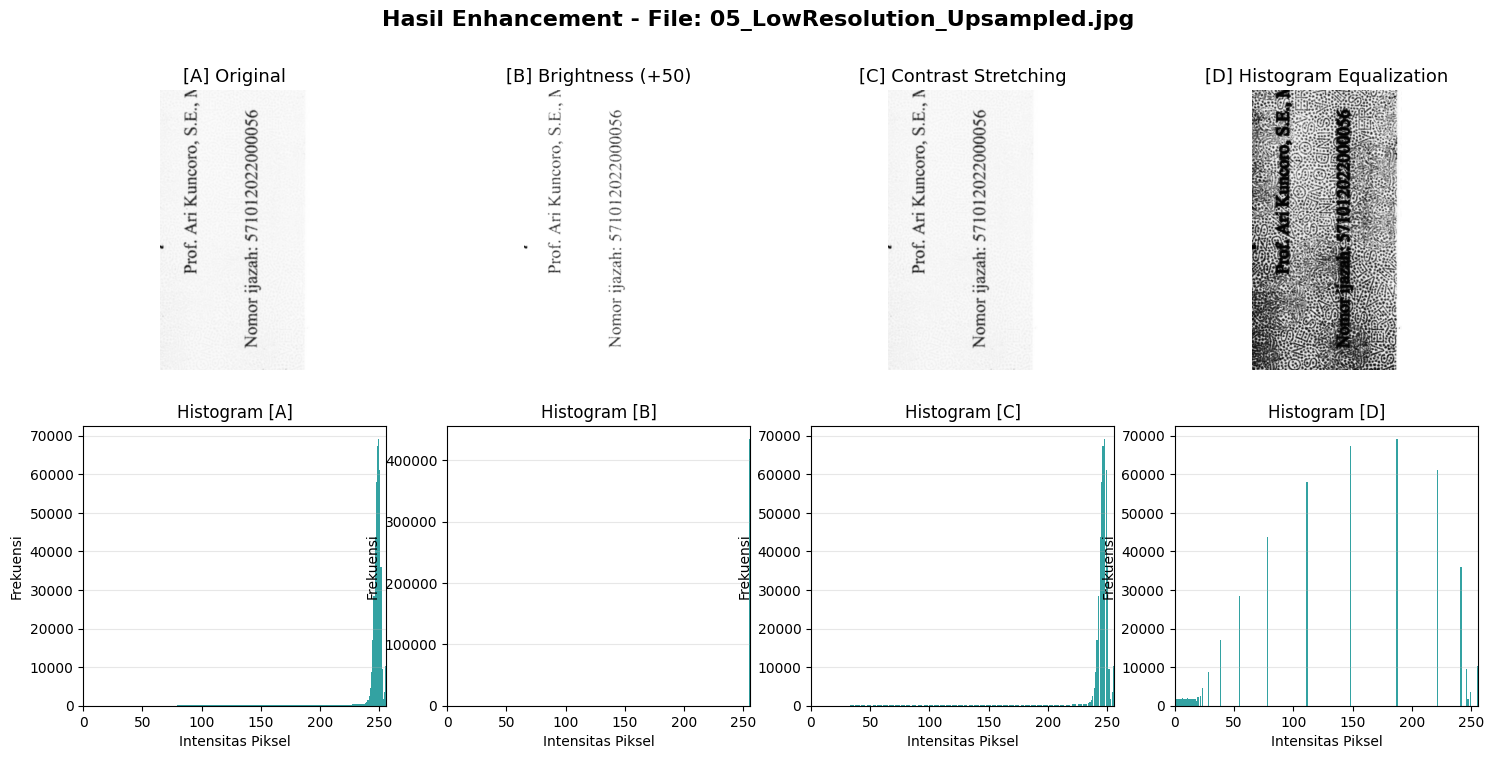

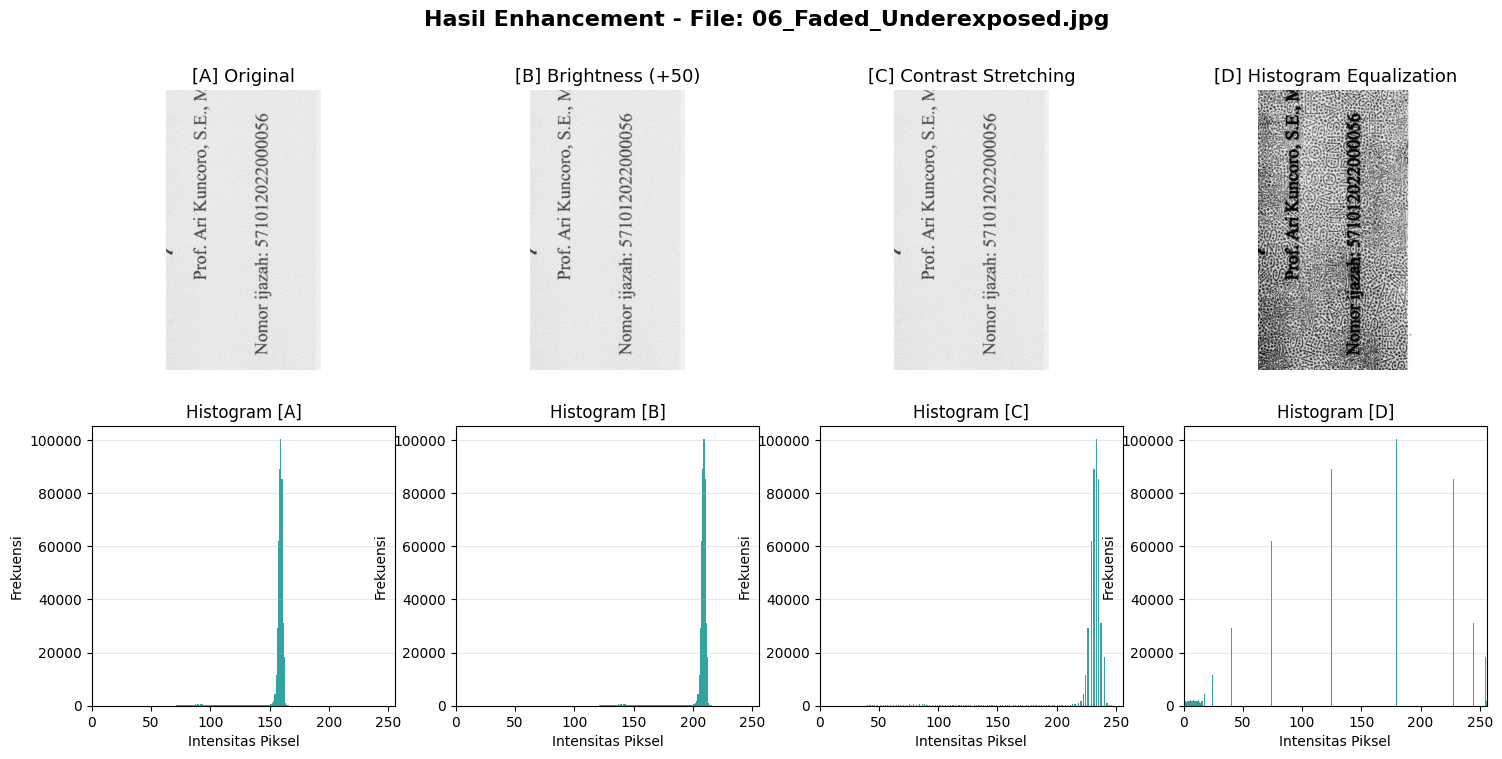

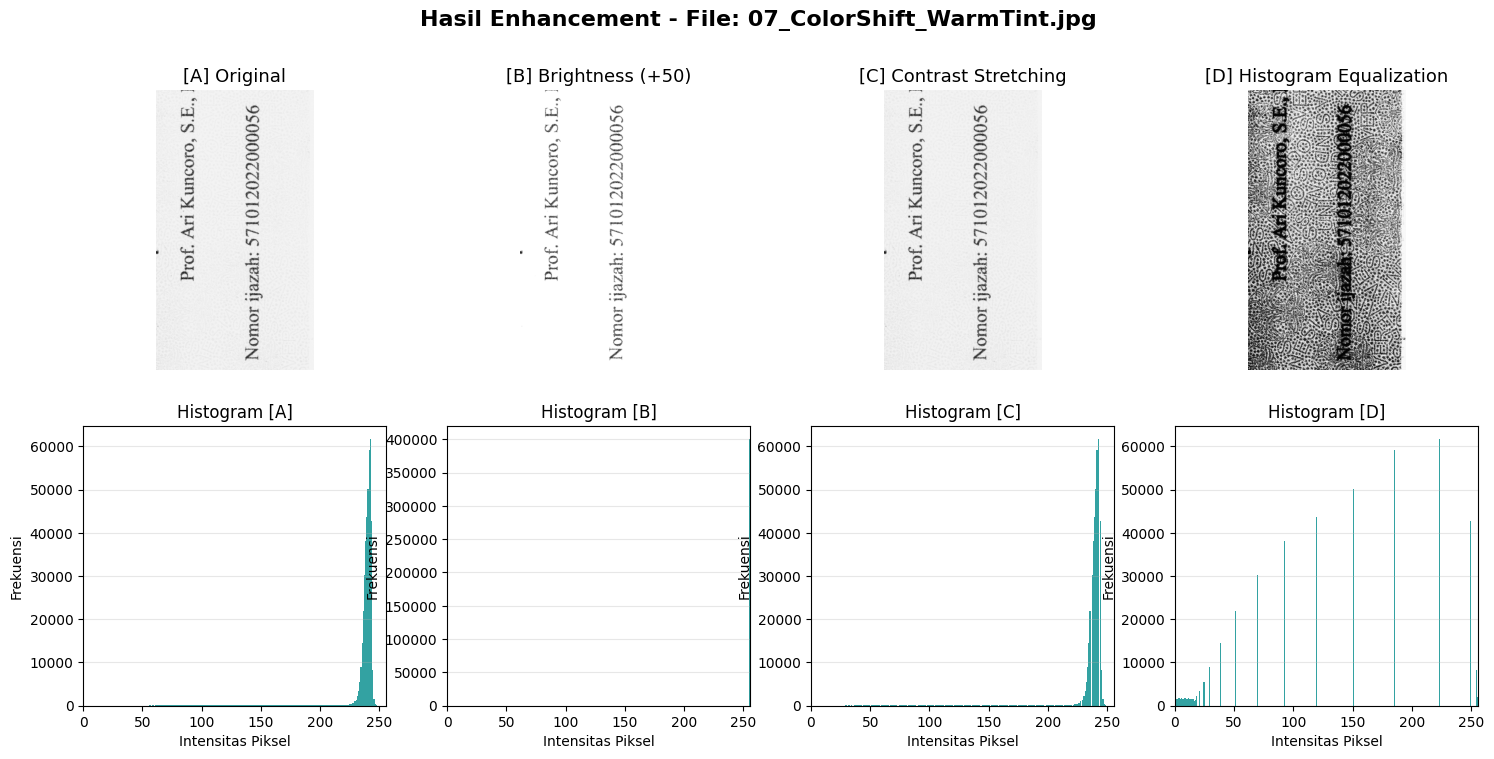

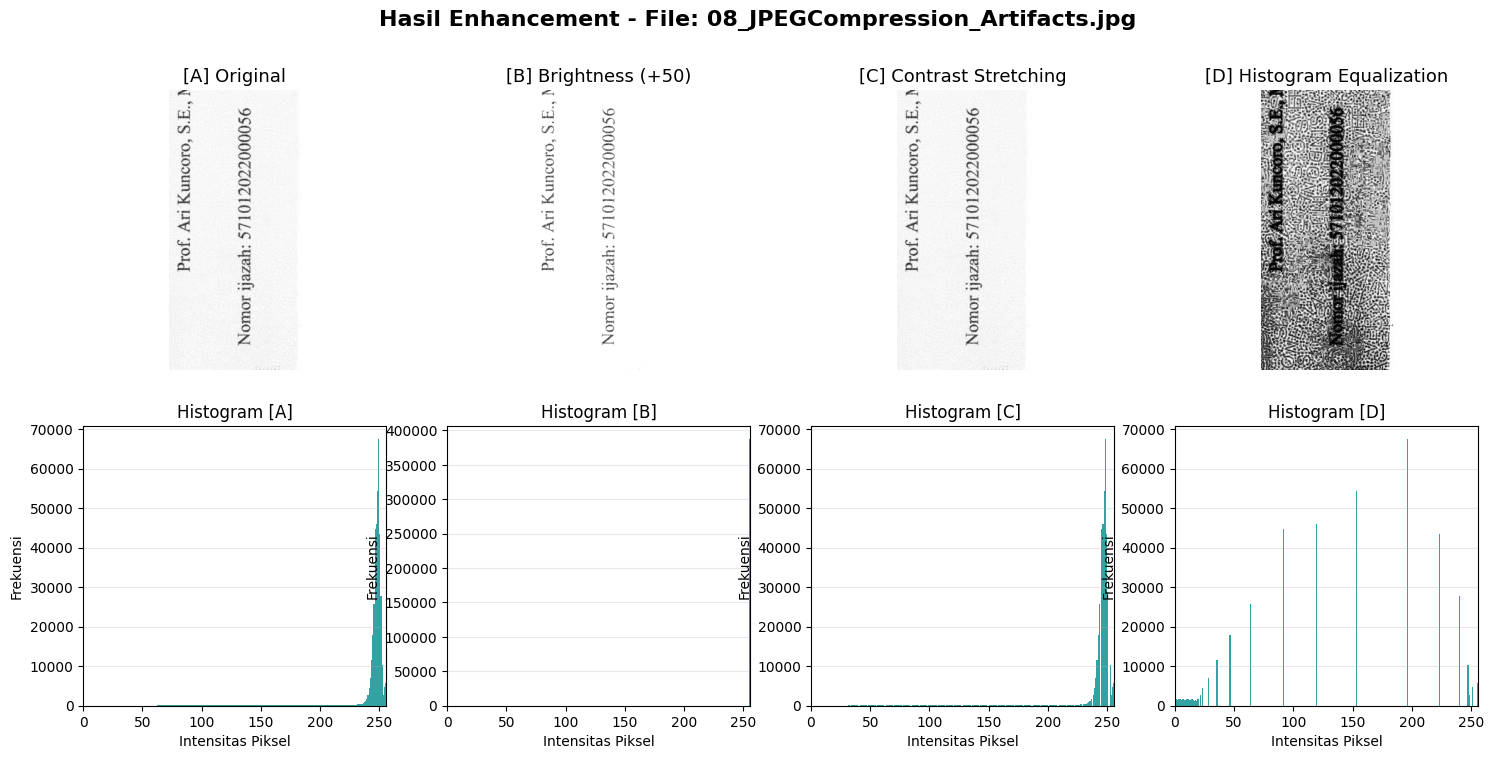

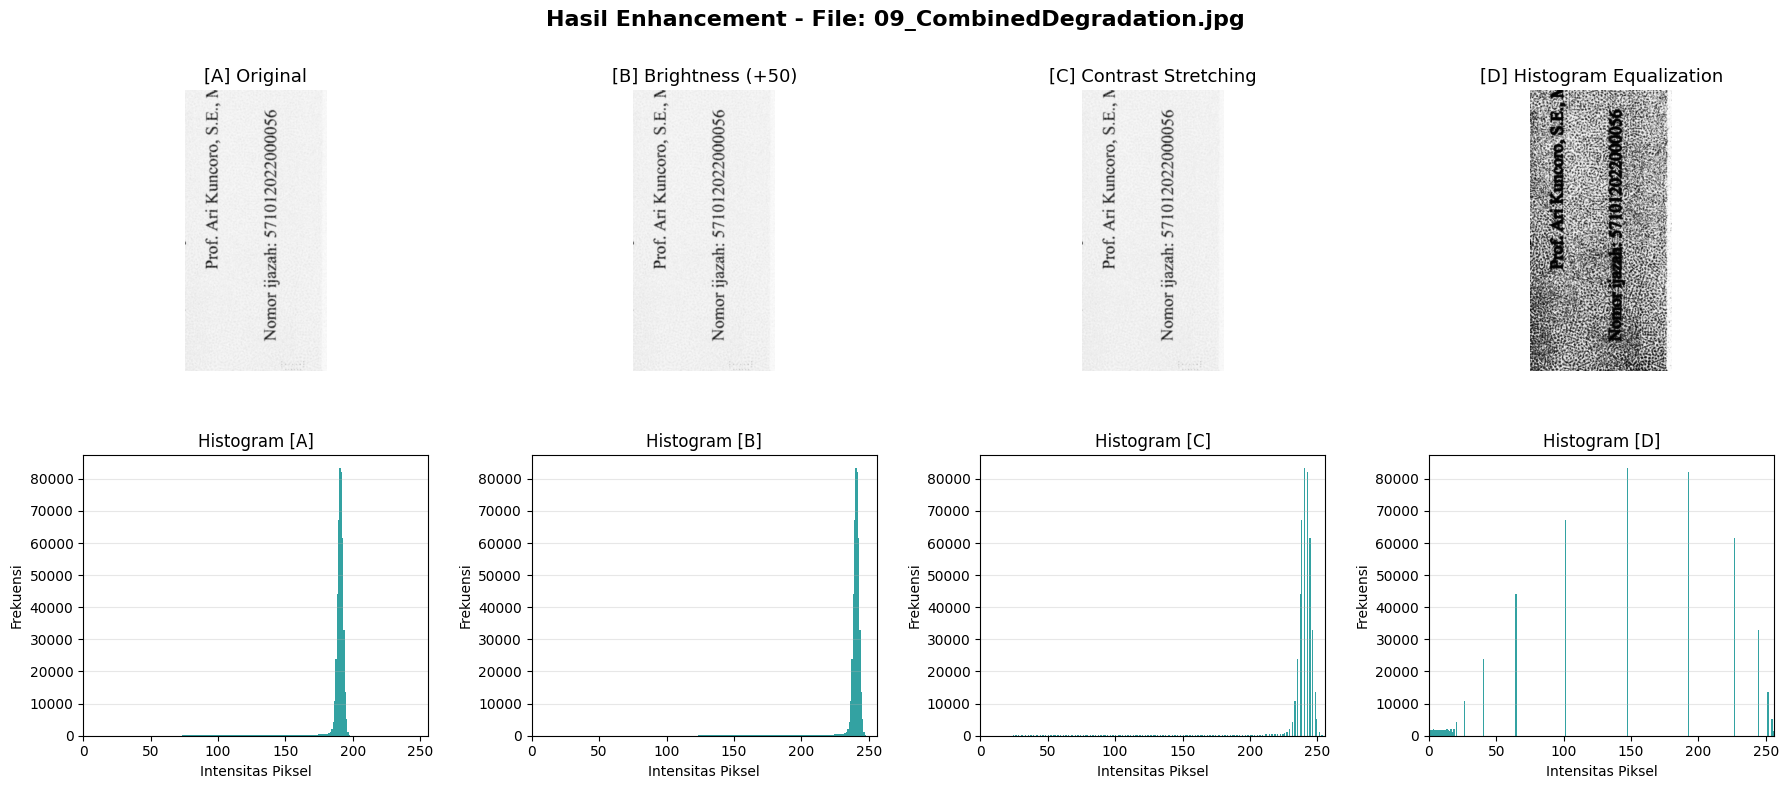

In [ ]:
for file_name in image_names:
    # 1. Baca citra (langsung dari file yang sudah di-crop)
    img = cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print(f"Error: Gambar '{file_name}' gagal dibaca.")
        continue

    original = img.copy()

        # [B] Brightness Adjustment (+50 intensitas)
    brightness = cv2.convertScaleAbs(original, alpha=1.0, beta=50)

        # [C] Contrast Stretching (Min-Max Normalization)
    contrast_stretch = np.zeros(original.shape, dtype=np.uint8)
    cv2.normalize(original, contrast_stretch, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)

        # [D] Histogram Equalization
    hist_eq = cv2.equalizeHist(original)

    images = [original, brightness, contrast_stretch, hist_eq]
    titles = ['[A] Original', '[B] Brightness (+50)', '[C] Contrast Stretching', '[D] Histogram Equalization']


    fig = plt.figure(figsize=(18, 8))
    fig.suptitle(f'Hasil Enhancement - File: {file_name}', fontsize=16, fontweight='bold')
    for i in range(4):
        # A. Menampilkan Gambar
        ax_img = plt.subplot(2, 4, i+1)
        ax_img.imshow(images[i], cmap='gray')
        ax_img.set_title(titles[i], fontsize=13)
        ax_img.axis('off') # Hilangkan garis sumbu pada gambar

        # B. Menampilkan Histogram
        ax_hist = plt.subplot(2, 4, i+5)
        ax_hist.hist(images[i].ravel(), bins=256, range=[0, 256], color='darkcyan', alpha=0.8)
        ax_hist.set_title(f'Histogram {titles[i][:3]}', fontsize=12)
        ax_hist.set_xlim([0, 256])
        ax_hist.set_xlabel('Intensitas Piksel')
        ax_hist.set_ylabel('Frekuensi')
        ax_hist.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.88, wspace=0.3, hspace=0.3) # Ruang untuk judul

    # Tampilkan figure untuk gambar ini
plt.show()

    # Garis pemisah visual di output Colab agar rapi
print("\n" + "="*80 + "\n")

Text(0.5, 0.98, 'Hasil Enhancement - File: 09_CombinedDegradation.jpg')

<Figure size 1800x800 with 0 Axes>

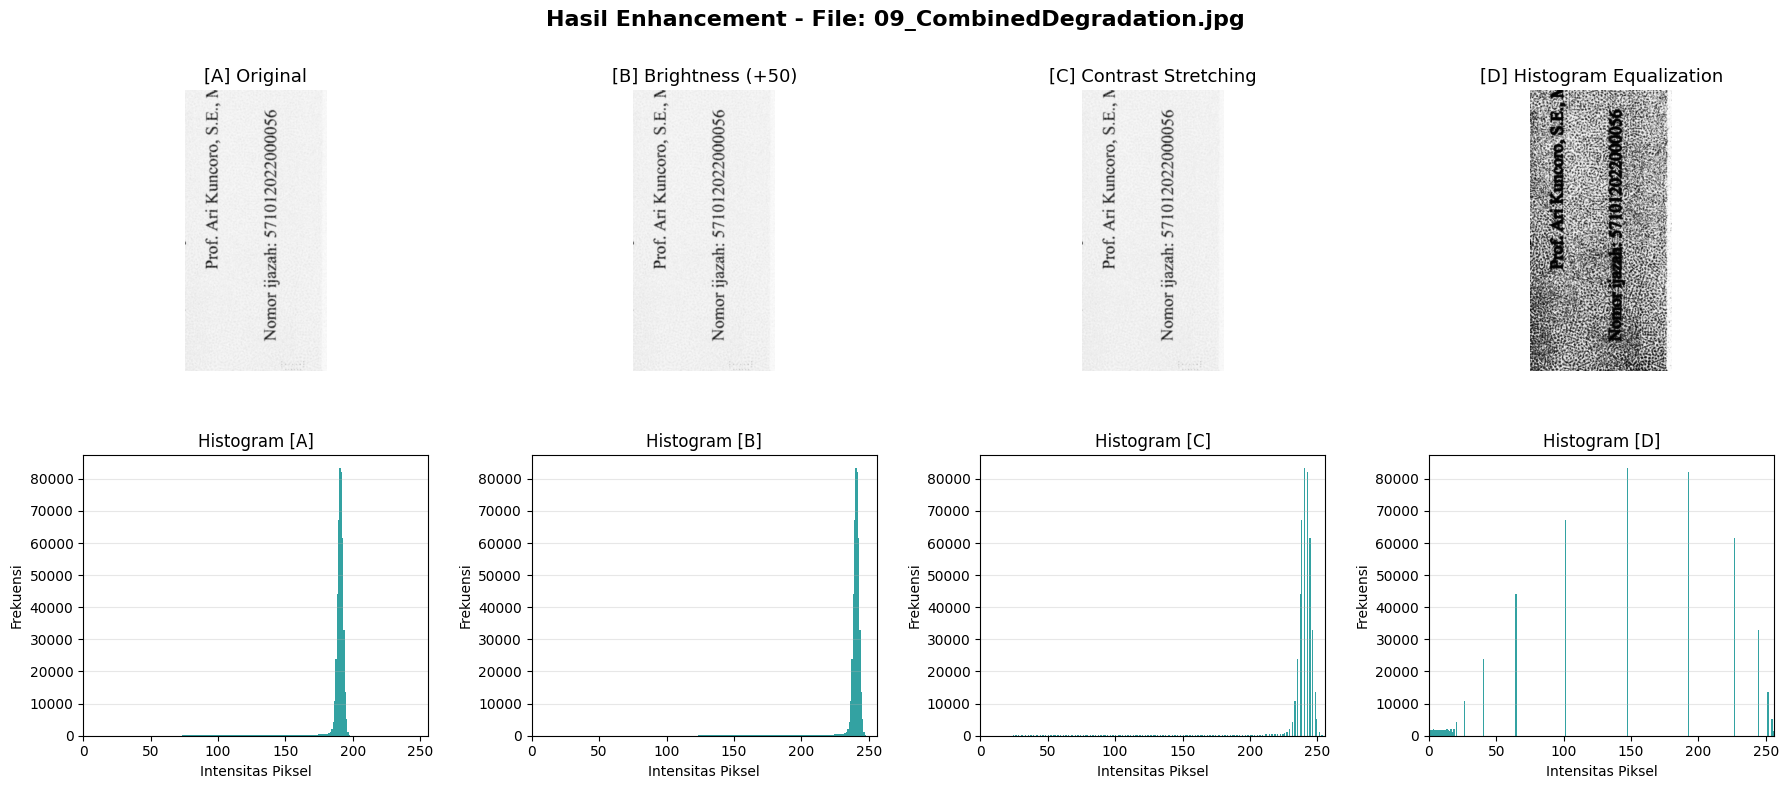